# Force & strain decomposition: gravity vs. Lorentz, elastic vs. thermal

This notebook compares, for two W7-X coil configurations, the relative importance of:

1. **Gravity body force vs. Lorentz body force** &nbsp;(`f_vol = f_Lorentz + ρg`, so `f_Lorentz = f_vol − ρg`)
2. **Elastic strain vs. thermal strain** &nbsp;(`ε_total = ε_elastic + ε_thermal`, with `ε_thermal = −itc·I`, `itc` = integral thermal contraction)

Configurations:

- **`n_275`** — single W7-X coil (coil 0), 275 quadpoints (the `w7x-convergence/w7x_coil_0_data/n_275` case), rebuilt via `shared.py`.
- **`movable`** — the optimized *movable* case from `w7x-optimization`, rebuilt from `Jstress_movable.json` (keeping its optimized discrete supports) with thermal contraction + gravity now enabled.

Both material/thermal/gravity parameters come from `properties.json` (316LN, Foussat et al. 2013), so the runs now contain **both** thermal contraction and gravity, making the two comparisons meaningful.

For each configuration we report volume-weighted **L2 norms** `‖·‖ = √(∫|·|² dV)` and render a row of four 3-D PyVista panels (gravity, Lorentz, elastic, thermal) sharing a force colorbar and a strain colorbar. Camera angles match `w7x-optimization/plot_pyvista.ipynb`.

In [1]:
# ── Setup ─────────────────────────────────────────────────────────────────────
import os, sys, glob, json, gc
# Run on CPU: the volumetric Biot-Savart for the multi-coil "movable" case needs
# several GB of single-buffer allocations, which overflows this 8 GB GPU.  CPU has
# ample RAM and the per-coil linear systems are small, so we use the UMFPACK solver.
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import jax_fem                       # forces setup_logger() to run before we mute it
import logging
jl = logging.getLogger('jax_fem')
jl.setLevel(logging.WARNING)
jl.handlers.clear()
jl.propagate = False

from pathlib import Path
import numpy as np

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

# n_275 is a large 3-D problem (~406k DOFs); UMFPACK's LU fill-in would exhaust
# RAM, so route the PETSc solver through MUMPS (sparse direct), exactly as the
# convergence study's PETSc variant does.  This patches jax_fem's petsc_solve to
# use a direct preonly/LU/MUMPS solve whenever solver='petsc' is requested.
from petsc4py import PETSc as _PETSc
import jax_fem.solver as _jfem_solver
_orig_petsc_solve = _jfem_solver.petsc_solve
def _petsc_solve_preonly_lu(A, b, ksp_type, pc_type):
    _PETSc.Options()['-ksp_type'] = 'preonly'
    _PETSc.Options()['-pc_type']  = 'lu'
    _PETSc.Options()['-pc_factor_mat_solver_type'] = 'mumps'
    return _orig_petsc_solve(A, b, 'preonly', 'lu')
_jfem_solver.petsc_solve = _petsc_solve_preonly_lu

import meshio
import pyvista as pv
from IPython.display import Image, display

# Repo root = directory holding this notebook (fem-data/).
REPO = Path.cwd()
assert (REPO / 'properties.json').exists(), f"properties.json not found in {REPO}"

# shared.py (w7x-convergence) supplies the n_275 mesh/support/geometry helpers.
sys.path.insert(0, str(REPO / 'w7x-convergence'))

OUT_ROOT = REPO / 'fem_data_compare'
FIG_DIR  = REPO / 'figures'
FIG_DIR.mkdir(exist_ok=True)
print("JAX devices:", jax.devices())

       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              



JAX devices: [CpuDevice(id=0)]


In [2]:
# ── Material / gravity options from the centralized properties.json ───────────
with open(REPO / 'properties.json') as f:
    PROPS = json.load(f)

_mat  = PROPS['material']
_grav = PROPS['gravity']

material_options = dict(
    E       = float(_mat['E_Pa']),
    nu      = float(_mat['nu']),
    density = float(_mat['density_kg_m3']),
    itc     = float(_mat['itc']),     # integral thermal contraction; eps_thermal = -itc * I
)
gravity_options = (
    dict(density=float(_mat['density_kg_m3']),
         g_vec=tuple(float(c) for c in _grav['g_vec_m_s2']))
    if _grav.get('enabled', False) else None
)

print("material_options:", material_options)
print("gravity_options :", gravity_options)

material_options: {'E': 205000000000.0, 'nu': 0.3, 'density': 8000.0, 'itc': 0.0029}
gravity_options : {'density': 8000.0, 'g_vec': (0.0, 0.0, -9.80665)}


In [3]:
# ── Configuration 1 builder: n_275 (single W7-X coil 0, 275 quadpoints) ───────
# Rebuilt with the same mesh/support/geometry as the convergence study, but now
# with thermal contraction (itc) + gravity enabled (via material_options/gravity_options).
import shared   # sets Agg backend + prints devices; we preview via IPython.display
from coilforce.coil_fem import CoilFEM
from coilforce.curve_jax import CurveXYZFourierJAX

N_QUADPOINTS = 275

def build_n275():
    curves_w7x, currents_w7x, _axis, _nfp, _bs = shared.load_w7x_data()
    quad = jnp.linspace(0.0, 1.0, N_QUADPOINTS, endpoint=False)
    fem = CoilFEM(
        base_curves_jax   = [CurveXYZFourierJAX(quadpoints=quad,
                                                dofs=curves_w7x[0].get_dofs(),
                                                order=curves_w7x[0].order)],
        base_currents_jax = [currents_w7x[0].current],
        nfp               = 1,        # single coil, no field-period symmetry
        stellsym          = False,
        mesh_options      = shared.mesh_options,
        material_options  = material_options,
        gravity_options   = gravity_options,
        base_support_fns  = shared.support_fn,
        base_support_dofs = shared.support_dofs,
        problem_options   = shared.problem_options | {'solver': 'petsc',
                                                      'adjoint_solver': 'petsc'},
    )
    return fem

JAX devices: [CpuDevice(id=0)]


In [4]:
# ── Configuration 2 builder: movable (optimized W7-X half-period, 5 base coils) ─
# The saved Jstress_movable.json predates the thermal/gravity additions, so we
# rebuild a fresh CoilFEMObjective reusing its optimized geometry + discrete
# supports, but injecting the new material_options (itc) + gravity_options.
# The loaded object is freed immediately so only one FEM lives on the GPU at a time.
from simsopt import load
from coilforce.simsopt_bridge import CoilFEMObjective

def build_movable():
    Jm = load(str(REPO / 'w7x-optimization' / 'Jstress_movable.json'))[0]
    obj = CoilFEMObjective(
        base_curves      = Jm._base_curves,
        base_currents    = Jm._base_currents,
        base_supports    = Jm._base_supports,      # optimized discrete clamps
        metrics          = Jm._metrics,
        metric_weights   = Jm._metric_weights,
        nfp              = Jm._nfp,
        stellsym         = Jm._stellsym,
        mesh_options     = Jm._mesh_options,
        material_options = material_options,
        gravity_options  = gravity_options,
        problem_options  = {**Jm._problem_options,
                            'solver': 'umfpack', 'adjoint_solver': 'umfpack'},
    )
    del Jm
    gc.collect()
    return obj.fem

In [5]:
# ── Field decomposition + L2 norms ────────────────────────────────────────────
# Force split:  f_vol = f_Lorentz + rho*g   ->   f_Lorentz = f_vol - rho*g.
# Strain split: eps_total = eps_elastic + eps_thermal, eps_thermal = -itc*I,
#               so eps_elastic = eps_total - eps_thermal.
# Magnitudes: |f| = Euclidean norm of the 3-vector; |eps| = Frobenius norm of the
#             3x3 tensor.  Per-cell values are quadrature-averaged for plotting.
# Volume-weighted L2 norm of a field q over the domain:  sqrt( sum_cells_quads |q|^2 * JxW ).

FORCE_KEYS  = {'gravity': 'gravity_force_Npm3', 'lorentz': 'lorentz_force_Npm3'}
STRAIN_KEYS = {'elastic': 'elastic_strain',     'thermal': 'thermal_strain'}

def compute_fields(fem):
    """Return per-coil dict of mesh + per-quad magnitudes + volume weights."""
    # run() does not fall back to the stored support DOFs, so pass them
    # explicitly (needed for the movable case's optimized discrete clamps).
    sd      = fem._base_support_dofs
    run     = fem.run(base_support_dofs=sd)
    strains = fem.compute_strain_tensors(base_support_dofs=sd)

    if fem.gravity_options is not None:
        rho = float(fem.gravity_options['density'])
        g   = np.asarray(fem.gravity_options.get('g_vec', (0.0, 0.0, -9.80665)), float)
        grav_vec = rho * g
    else:
        grav_vec = np.zeros(3)
    grav_mag = float(np.linalg.norm(grav_vec))

    per_coil = []
    for i, coil_mesh in enumerate(fem.meshes):
        f_vol   = np.asarray(run['f_vol'][i])              # (n_cells, n_quads, 3)
        lorentz = f_vol - grav_vec[None, None, :]
        eps_tot = np.asarray(strains['eps_total'][i])      # (n_cells, n_quads, 3, 3)
        eps_th  = np.asarray(strains['eps_thermal'][i])    # (3, 3)
        eps_el  = eps_tot - eps_th[None, None, :, :]

        nC, nQ = f_vol.shape[0], f_vol.shape[1]
        JxW = np.asarray(fem._problems[i].JxW).reshape(nC, nQ)   # volume element [m^3]

        per_coil.append(dict(
            points    = np.asarray(run['mesh_points'][i], float),
            cells     = np.asarray(coil_mesh.cells, np.int32),
            cell_type = coil_mesh.meshio_cell_type,
            JxW       = JxW,
            gravity   = np.full((nC, nQ), grav_mag),            # spatially uniform
            lorentz   = np.linalg.norm(lorentz, axis=2),
            elastic   = np.linalg.norm(eps_el, axis=(2, 3)),
            thermal   = np.full((nC, nQ), float(np.linalg.norm(eps_th))),  # uniform
        ))
    return per_coil

def l2_norm(per_coil, field):
    """Volume-weighted L2 norm sqrt(integral |field|^2 dV) over all coils."""
    total = sum(float(np.sum(c[field] ** 2 * c['JxW'])) for c in per_coil)
    return float(np.sqrt(total))

def write_vtus(per_coil, out_dir, prefix='coil_'):
    """Write one VTU per coil with quad-averaged cell magnitudes for plotting."""
    os.makedirs(out_dir, exist_ok=True)
    paths = []
    for i, c in enumerate(per_coil):
        cell_avg = lambda q: np.asarray(q.mean(axis=1), float)   # (n_cells,)
        m = meshio.Mesh(
            points=c['points'],
            cells=[(c['cell_type'], c['cells'])],
            cell_data={
                FORCE_KEYS['gravity']:  [cell_avg(c['gravity'])],
                FORCE_KEYS['lorentz']:  [cell_avg(c['lorentz'])],
                STRAIN_KEYS['elastic']: [cell_avg(c['elastic'])],
                STRAIN_KEYS['thermal']: [cell_avg(c['thermal'])],
            },
        )
        p = os.path.join(out_dir, f'{prefix}{i:02d}.vtu')
        m.write(p)
        paths.append(p)
    return paths

In [6]:
# ── Solve both configurations, write VTUs, report L2 norms ────────────────────
# Built/solved one at a time, freeing GPU memory between cases (8 GB device).
CASES = [
    ('n_275',   build_n275,   OUT_ROOT / 'n_275'),
    ('movable', build_movable, OUT_ROOT / 'movable'),
]

results = {}
for name, builder, out_dir in CASES:
    print(f"[{name}] building + solving ...")
    fem = builder()
    per_coil = compute_fields(fem)              # holds only host (numpy) arrays
    write_vtus(per_coil, str(out_dir))
    results[name] = dict(
        folder = str(out_dir),
        L2 = {k: l2_norm(per_coil, k) for k in
              ('gravity', 'lorentz', 'elastic', 'thermal')},
    )
    del fem, per_coil                           # release GPU FEM/solver resources
    jax.clear_caches()
    gc.collect()
    print(f"[{name}] done.")

# ── Report ────────────────────────────────────────────────────────────────────
print("\nVolume-weighted L2 norms  ||q|| = sqrt( integral |q|^2 dV )\n" + "=" * 64)
for name in results:
    L = results[name]['L2']
    print(f"\n{name}")
    print(f"  Force  [N/m^3 * sqrt(m^3)]:  "
          f"||gravity|| = {L['gravity']:.4e}   ||Lorentz|| = {L['lorentz']:.4e}   "
          f"gravity/Lorentz = {L['gravity']/L['lorentz']:.3e}")
    print(f"  Strain [-      * sqrt(m^3)]:  "
          f"||thermal|| = {L['thermal']:.4e}   ||elastic|| = {L['elastic']:.4e}   "
          f"thermal/elastic = {L['thermal']/L['elastic']:.3e}")

[n_275] building + solving ...


[n_275] done.
[movable] building + solving ...


[movable] done.

Volume-weighted L2 norms  ||q|| = sqrt( integral |q|^2 dV )

n_275
  Force  [N/m^3 * sqrt(m^3)]:  ||gravity|| = 4.5900e+04   ||Lorentz|| = 4.8871e+07   gravity/Lorentz = 9.392e-04
  Strain [-      * sqrt(m^3)]:  ||thermal|| = 2.9387e-03   ||elastic|| = 3.9509e-04   thermal/elastic = 7.438e+00

movable
  Force  [N/m^3 * sqrt(m^3)]:  ||gravity|| = 1.0164e+05   ||Lorentz|| = 1.3104e+08   gravity/Lorentz = 7.756e-04
  Strain [-      * sqrt(m^3)]:  ||thermal|| = 6.5073e-03   ||elastic|| = 9.9704e-04   thermal/elastic = 6.527e+00


In [7]:
# ── PyVista helpers (camera matches w7x-optimization/plot_pyvista.ipynb) ──────
import vtk  # noqa: F401

# camera / layout knobs (same convention as plot_pyvista.ipynb)
zoom        = 1.6     # >1 zooms in
azimuth_deg = 180     # rotate camera about z through the scene center
panel_px    = 900     # square panel size in pixels

def rotate_camera_xy(plotter, angle_deg, center=(0.0, 0.0, 0.0)):
    """Rotate the (shared) camera in xy about the z-axis through ``center``."""
    th = np.radians(angle_deg)
    c, s = np.cos(th), np.sin(th)
    R = np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]])
    ctr = np.asarray(center, dtype=float)
    cam = plotter.camera
    cam.position    = tuple(ctr + R @ (np.asarray(cam.position)    - ctr))
    cam.focal_point = tuple(ctr + R @ (np.asarray(cam.focal_point) - ctr))
    cam.up          = tuple(R @ np.asarray(cam.up))

def values(mesh, q):
    return np.asarray(mesh.cell_data[q]).ravel()

# Merge each case's per-coil VTUs into a single mesh (as in plot_pyvista.ipynb).
meshes = {}
for name in results:
    parts = [pv.read(p) for p in sorted(glob.glob(os.path.join(results[name]['folder'], '*.vtu')))]
    meshes[name] = pv.merge(parts)

# Shared color ranges so panels are comparable across both cases.
force_max  = max(values(meshes[n], FORCE_KEYS[k]).max()
                 for n in meshes for k in FORCE_KEYS)
strain_max = max(values(meshes[n], STRAIN_KEYS[k]).max()
                 for n in meshes for k in STRAIN_KEYS)
force_clim  = (0.0, float(force_max))
strain_clim = (0.0, float(strain_max))

# Rotation center = mean of all vertices across both cases.
center = np.vstack([np.asarray(meshes[n].points) for n in meshes]).mean(axis=0)
print("force_clim  =", force_clim)
print("strain_clim =", strain_clim)

force_clim  = (0.0, 195057135.42611116)
strain_clim = (0.0, 0.0050229473419497435)


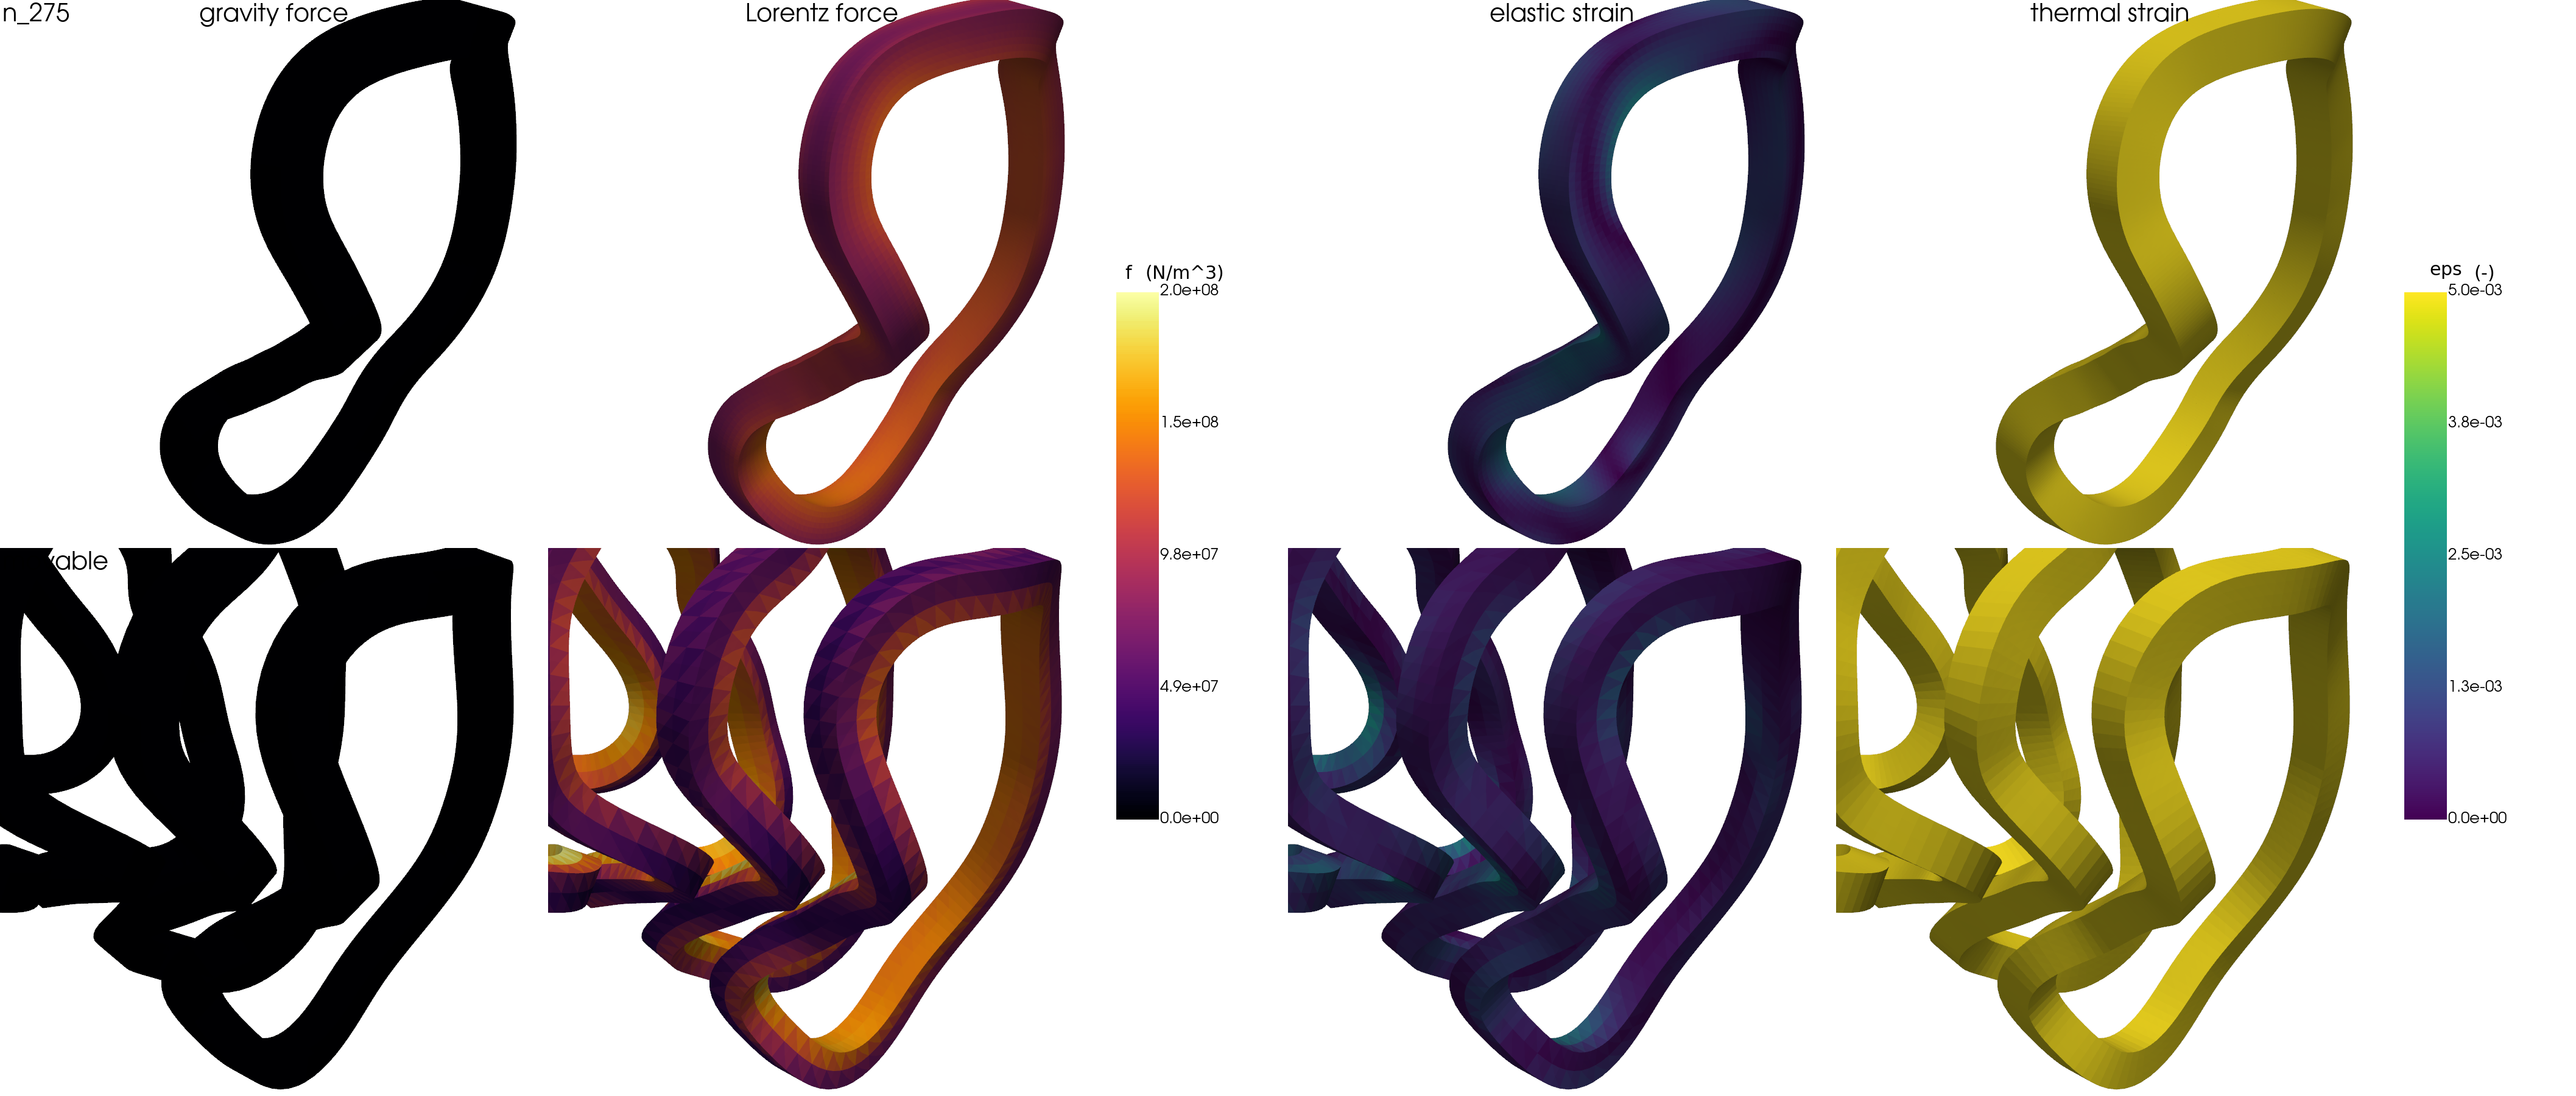

In [8]:
# ── 3-D comparison figure ─────────────────────────────────────────────────────
# Layout per case-row:  gravity | Lorentz | [force colorbar] | elastic | thermal | [strain colorbar]
# Columns 2 and 5 hold the two shared colorbars (spanning both case rows).
case_names  = list(results.keys())
nrows       = len(case_names)
ncols       = 6
cbar_frac   = 0.35
col_weights = [1.0, 1.0, cbar_frac, 1.0, 1.0, cbar_frac]

force_cmap, strain_cmap = 'inferno', 'viridis'

# (col, cell_data key, clim, cmap, column title)
PANELS = [
    (0, FORCE_KEYS['gravity'],  force_clim,  force_cmap,  'gravity force'),
    (1, FORCE_KEYS['lorentz'],  force_clim,  force_cmap,  'Lorentz force'),
    (3, STRAIN_KEYS['elastic'], strain_clim, strain_cmap, 'elastic strain'),
    (4, STRAIN_KEYS['thermal'], strain_clim, strain_cmap, 'thermal strain'),
]

p = pv.Plotter(
    shape=(nrows, ncols), off_screen=True,
    groups=[(np.s_[:], 2), (np.s_[:], 5)],     # the two colorbar columns span all rows
    col_weights=col_weights,
    window_size=(int(panel_px * sum(col_weights)), panel_px * nrows),
    border=False,
)

force_mapper = strain_mapper = None
for r, name in enumerate(case_names):
    for col, key, clim, cmap, title in PANELS:
        p.subplot(r, col)
        if r == 0:
            p.add_text(title, font_size=16, position='upper_edge')
        if col == 0:
            p.add_text(name, font_size=16, position='upper_left')
        # Use a fresh mesh per panel with a single active scalar; reusing one
        # mesh object across add_mesh calls makes PyVista share active scalars
        # between panels (cross-talk), so copy + set_active_scalars per panel.
        pm = meshes[name].copy(deep=True)
        pm.set_active_scalars(key, preference='cell')
        actor = p.add_mesh(pm, scalars=key, preference='cell',
                           clim=clim, cmap=cmap, show_scalar_bar=False)
        if cmap == force_cmap and force_mapper is None:
            force_mapper = actor.mapper
        if cmap == strain_cmap and strain_mapper is None:
            strain_mapper = actor.mapper

# Shared camera for all panels.
p.link_views()
p.subplot(0, 0)
p.view_isometric()
rotate_camera_xy(p, azimuth_deg, center=center)
p.camera.zoom(zoom)

# Force colorbar (column 2).
p.subplot(0, 2)
p.add_scalar_bar(title='|f|  (N/m^3)', mapper=force_mapper, vertical=True,
                 position_x=0.1, position_y=0.25, height=0.5, width=0.6,
                 title_font_size=30, label_font_size=26, fmt='%.1e')
# Strain colorbar (column 5).
p.subplot(0, 5)
p.add_scalar_bar(title='|eps|  (-)', mapper=strain_mapper, vertical=True,
                 position_x=0.1, position_y=0.25, height=0.5, width=0.6,
                 title_font_size=30, label_font_size=26, fmt='%.1e')

fig_path = FIG_DIR / 'force_strain_comparison.png'
p.screenshot(str(fig_path))
p.close()
pv.close_all()
print("saved", fig_path)
display(Image(str(fig_path)))